# Training an NER model for product attributes extraction from given caption

To address the absence of explicit columns for brand names and product-specific attributes (e.g., “turtleneck,” “slim fit” these are considered as other product attributes), a custom Named Entity Recognition (NER) model was trained to extract these entities from raw captions.
1. The task was framed as a multi-label sequence tagging problem using BIO (Begin-Inside-Outside) format.
2. The model was trained on labeled caption data with five categories: Gender, Base Colour, Brand, Article Type, and other Product Attribute class.
3. Instead of generating new words, the model tagged existing tokens in the captions that belonged to these categories.

This allowed automatic transformation of unstructured captions into consistent, structured templates, which improved model focus during training. Rather than requiring CLIP to infer relationships across varied sentence structures, the structured format provided a clearer mapping between text and visual concepts, enhancing retrieval and attention performance.

## Data Import

In [ ]:
import pandas as pd
df = pd.read_csv('/content/fashion-dataset/styles.csv',on_bad_lines="skip")
df.shape

(44424, 10)

In [ ]:
cat = ['Home Furnishing','Vouchers',"Sports Accessories","Beauty Accessories","Wristbands","Water Bottle","Umbrellas","Perfumes"]
df = df[~df['subCategory'].isin(cat)]

In [ ]:
cat = ['Home Furnishing','Vouchers',"Sports Accessories","Beauty Accessories","Wristbands","Water Bottle","Umbrellas","Perfumes"]
df = df[~df['subCategory'].isin(cat)]
import numpy as np
import textwrap

In [ ]:
df.rename(columns={'productDisplayName': 'caption'}, inplace=True)
df.columns

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'caption'],
      dtype='object')

In [ ]:
print(df.head().iloc[0])

id                                           15970
gender                                         Men
masterCategory                             Apparel
subCategory                                Topwear
articleType                                 Shirts
baseColour                               Navy Blue
season                                        Fall
year                                        2011.0
usage                                       Casual
caption           Turtle Check Men Navy Blue Shirt
Name: 0, dtype: object


In [ ]:
df['caption']

,caption
0,Turtle Check Men Navy Blue Shirt
1,Peter England Men Party Blue Jeans
2,Titan Women Silver Watch
3,Manchester United Men Solid Black Track Pants
4,Puma Men Grey T-shirt
...,...
44419,Gas Men Caddy Casual Shoe
44420,Lotto Men's Soccer Track Flip Flop
44421,Puma Men Graphic Stellar Blue Tshirt
44422,Rasasi Women Blue Lady Perfume


## Captions exploration

Here we explored what extra data(brand name, other product attribute) is present in the caption other than the pre defined attributes(such as color, gender, articleType) and pattern of their occurence and some textual issues with the data(such as t-shirt, T - shirt being recognised as different etc).

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('wordnet')

nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

def lemmatize_text1(text):
    tokens = word_tokenize(text.lower())
    return " ".join([lemmatizer.lemmatize(tok) for tok in tokens])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def extract_slots_from_caption(row):
    caption = lemmatize_text1(str(row['caption']))

    def safe_lemma(val):
        return lemmatizer.lemmatize(str(val).lower()) if pd.notnull(val) else ""

    slots = {
        'gender': safe_lemma(row['gender']) in caption,
        'masterCategory': safe_lemma(row['masterCategory']) in caption,
        'articleType': safe_lemma(row['articleType']) in caption,
        'subCategory': safe_lemma(row['subCategory']) in caption,
        'baseColour': safe_lemma(row['baseColour']) in caption,
        'usage': safe_lemma(row['usage']) in caption,
        'season': safe_lemma(row['season']) in caption,
        'year': (str(int(row['year'])) in caption) if pd.notnull(row['year']) else False
    }

    return pd.Series(slots)


In [ ]:
df.isna().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,316
caption,7


In [ ]:
slot_matrix = df.apply(extract_slots_from_caption, axis=1)

In [ ]:
slot_matrix

,gender,masterCategory,articleType,subCategory,baseColour,usage,season,year
0,True,False,True,False,True,False,False,False
1,True,False,True,False,True,False,False,False
2,True,False,True,True,True,False,False,False
3,True,False,False,False,True,False,False,False
4,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...
44419,True,False,False,True,False,True,False,False
44420,True,False,False,False,False,False,False,False
44421,True,False,False,False,True,False,False,False
44422,True,False,False,False,True,False,False,False


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=20, random_state=42)
df['template_cluster'] = kmeans.fit_predict(slot_matrix.astype(int))

In [ ]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,0
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,0
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,1
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,2
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,2


In [ ]:
# gender-masterCategory-articleType-subCategory-baseColour-usage-season-year
template_patterns = slot_matrix.astype(int).astype(str).agg('-'.join, axis=1)
df['template_pattern'] = template_patterns
df['template_pattern'].value_counts()

,count
template_pattern,
1-0-1-0-1-0-0-0,13757
1-0-0-0-1-0-0-0,8878
1-0-1-1-1-0-0-0,7292
1-0-0-1-1-1-0-0,3057
1-0-0-1-1-0-0-0,2893
1-0-0-0-0-0-0-0,1530
0-0-1-0-1-0-0-0,1137
1-0-1-0-0-0-0-0,1096
0-0-0-0-1-0-0-0,809


In [ ]:
df[df['template_cluster']==0].head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster,template_pattern
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,0,1-0-1-0-1-0-0-0
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,0,1-0-1-0-1-0-0-0
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt,0,1-0-1-0-1-0-0-0
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt,0,1-0-1-0-1-0-0-0
15,12369,Men,Apparel,Topwear,Shirts,Purple,Fall,2011.0,Formal,Reid & Taylor Men Check Purple Shirts,0,1-0-1-0-1-0-0-0


In [ ]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()


def normalize_fashion_text(text):
    text = text.lower()

    # Replace known fashion terms (can expand as needed)
    replacements = {
        "t-shirts": "tshirt",
        "t-shirt": "tshirt",
        "t shirts": "tshirt",
        "t shirt": "tshirt",
        "flip flops": "flipflop",
        "flip flop": "flipflop",
        "sneakers": "shoe",
        "shoes":"shoe",
        "shirts": "shirt",
        "jeans": "jean",
        "sandals": "sandal",
        "shoes": "shoe",
        "trousers": "pant",
    }


    for k, v in replacements.items():
        text = text.replace(k, v)

    # Remove punctuation (keep spaces only)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
def lemmatize_text(text):
    text = normalize_fashion_text(text)
    tokens = word_tokenize(text)

    # Lemmatize and remove non-alphabetic tokens
    cleaned = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok.isalpha()  # remove numbers, etc.
    ]

    return cleaned  # returns a list of clean tokens


In [ ]:
def clean_caption(row):
    caption_tokens = lemmatize_text(str(row.get('caption', '')))

    def tokenize_metadata(val):
        if pd.notnull(val):
            return set(lemmatize_text(str(val)))
        else:
            return set()

    metadata_tokens = (
        tokenize_metadata(row.get('gender')) |
        tokenize_metadata(row.get('articleType')) |
        tokenize_metadata(row.get('subCategory')) |
        tokenize_metadata(row.get('baseColour')) |
        tokenize_metadata(row.get('usage')) |
        tokenize_metadata(row.get('season')) |
        set([str(int(row['year']))]) if pd.notnull(row.get('year')) else set()
    )

    cleaned_tokens = [tok for tok in caption_tokens if tok not in metadata_tokens]

    return ' '.join(cleaned_tokens)
df['caption_residual'] = df.apply(clean_caption, axis=1)

In [ ]:
df['caption_residual']

,caption_residual
0,turtle check
1,peter england party
2,titan
3,manchester united solid
4,puma
...,...
44419,gas caddy
44420,lotto s soccer track
44421,puma graphic stellar
44422,rasasi lady


In [ ]:
# observing patterns in the residual parts of the caption
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 3), min_df=5, stop_words='english')
X = vectorizer.fit_transform(df['caption_residual'])

# Get most common residual n-grams
ngram_counts = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)
sorted_ngrams = sorted(ngram_counts, key=lambda x: x[1], reverse=True)

for ngram, count in sorted_ngrams[:30]:
    print(f"{ngram} — {count}")

printed — 3434
nike — 2323
puma — 2097
adidas — 2080
dial — 1745
polo — 1656
color — 1536
united — 1507
benetton — 1430
united color — 1401
color benetton — 1396
united color benetton — 1395
solid — 1344
check — 1266
striped — 1037
red — 851
kid — 822
stripe — 754
fabindia — 751
catwalk — 744
gini — 721
jony — 719
gini jony — 718
arrow — 703
fastrack — 691
wrangler — 687
white — 673
lino — 655
lino perros — 655
perros — 655


In [ ]:
len(sorted_ngrams)

4873

In [ ]:
ngrams = [ngram for ngram, _ in sorted_ngrams[:]]

In [ ]:
len(ngrams)

4873

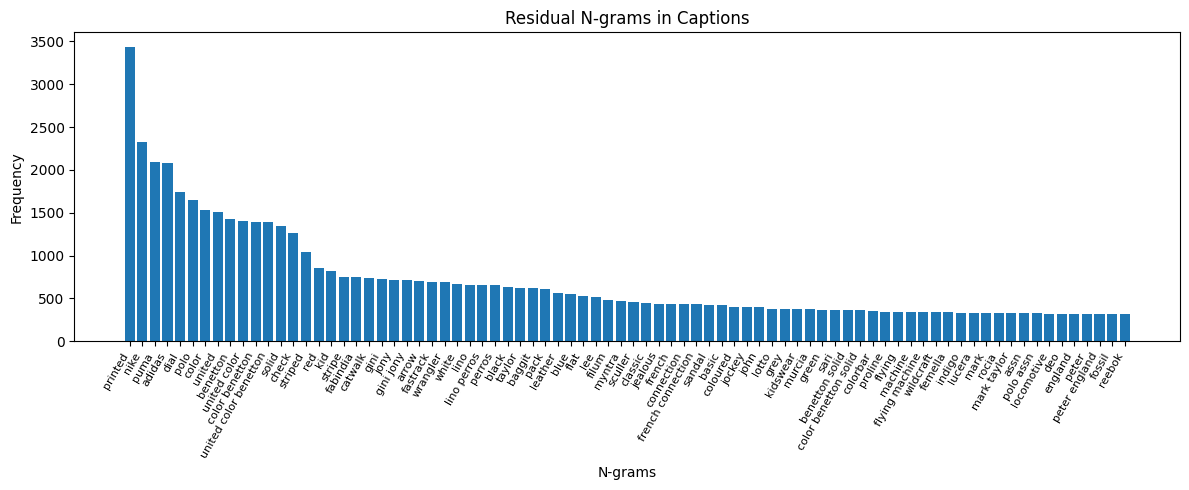

In [ ]:
import matplotlib.pyplot as plt

def plot_ngrams(start,end,ngrams):
    # Top N n-grams

    top_ngrams = ngrams[start:end]
    ngrams, counts = zip(*top_ngrams)

    # Plot vertical bar chart
    plt.figure(figsize=(12, 5))
    plt.bar(ngrams, counts)
    plt.title("Residual N-grams in Captions")
    plt.xlabel("N-grams")
    plt.ylabel("Frequency")
    plt.xticks(rotation=60, ha='right',size=8)  # 👈 Rotate and align x-axis labels
    plt.tight_layout()
    plt.show()

plot_ngrams(0,80,sorted_ngrams)

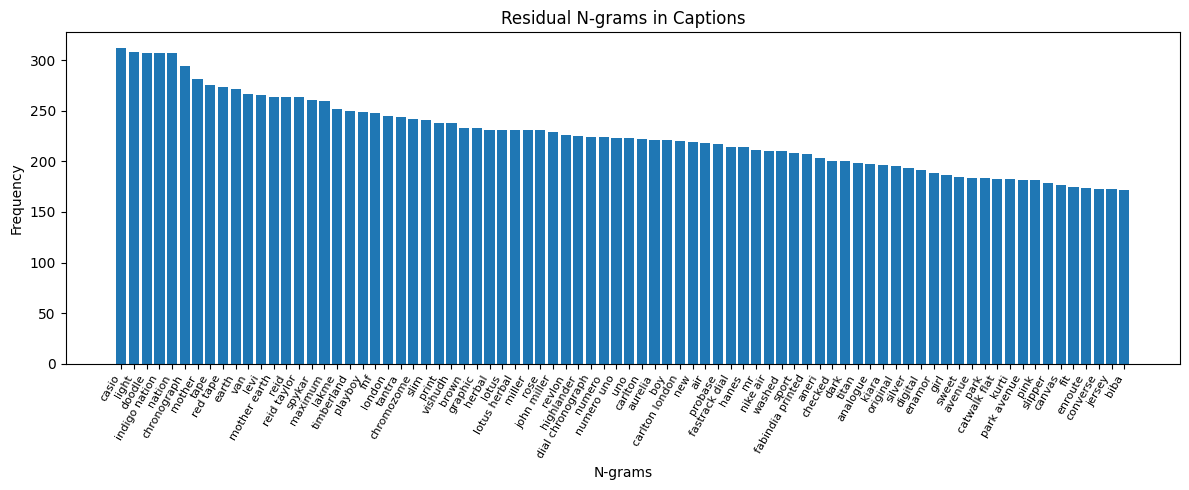

In [ ]:
plot_ngrams(80,160,sorted_ngrams)

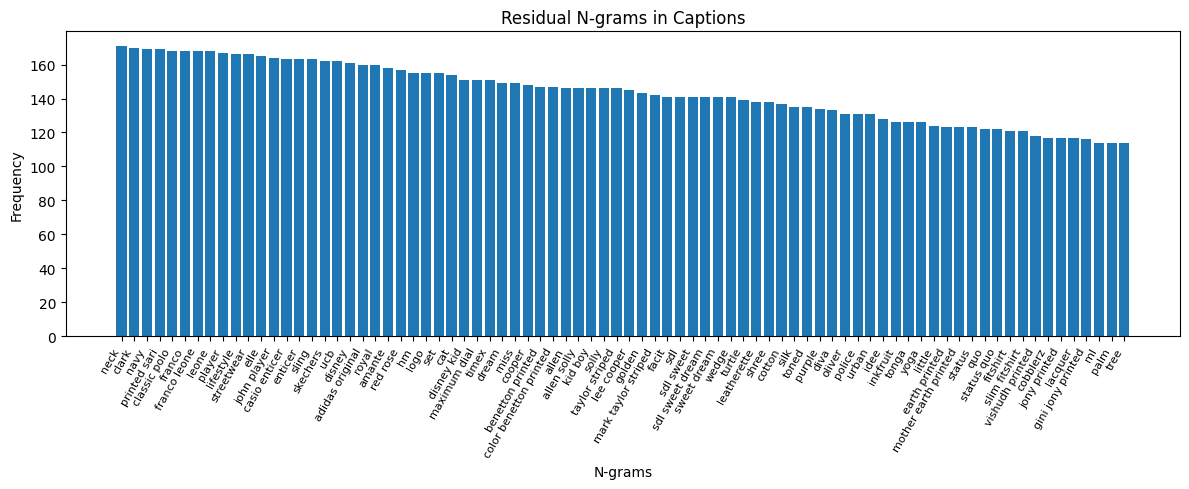

In [ ]:
plot_ngrams(160,240,sorted_ngrams)

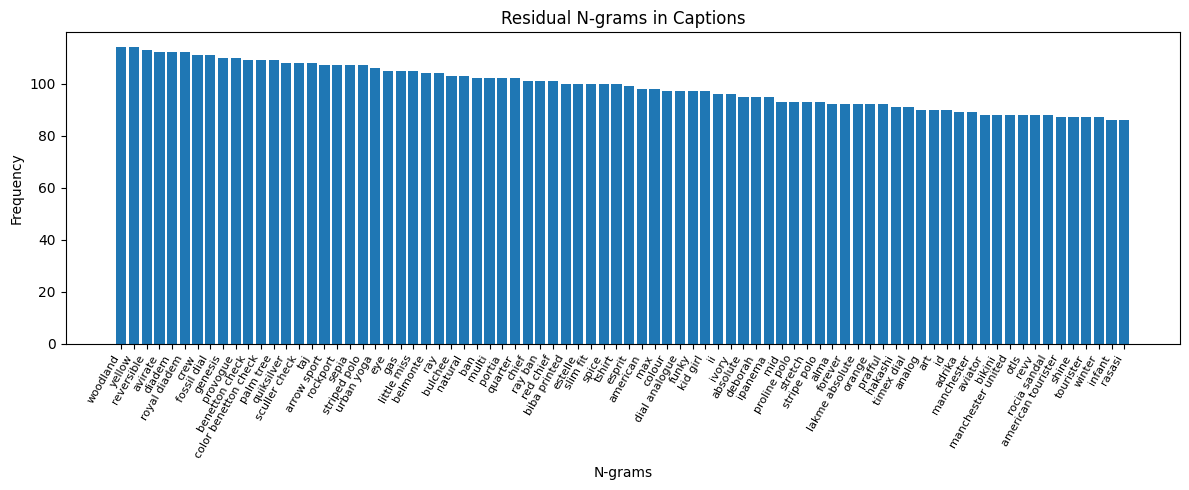

In [ ]:
plot_ngrams(240,320,sorted_ngrams)

In [ ]:
def is_prefix_ngram(ngram, captions, min_count=5):
    count = sum(
        str(caption).lower().startswith(ngram)
        for caption in captions
        if pd.notnull(caption)
    )
    return count >= min_count

In [ ]:
brand_candidates = [ng for ng in ngrams if is_prefix_ngram(ng, df['caption_residual'])]

In [ ]:
len(brand_candidates)

In [ ]:
df['caption_residual'].to_csv('text.csv')

In [ ]:
df.to_csv('t.csv')

In [ ]:
s = pd.read_csv('text.csv')
s.shape

(44392, 2)

## Identifying brands

After doing the necessary exploration, found some brand names from the above graphs of ngrams. Now further exploration and techniques are applied to extract brand names that are present as mono, bi, tri grams. The similar ngrams are grouped together in sets(named as collapsed_groups in code) such as "{'peter','england','perter england'}", with which I was able to identify proper brand names and form a list of the brand names as many as possible.

In [ ]:
# Sort by descending length (keep longer names first)
brand_candidates_sorted = sorted(set(brand_candidates), key=lambda x: -len(x))

# Keep only the unique longest forms
final_brands = []
for brand in brand_candidates_sorted:
    if not any(brand in b and brand != b for b in final_brands):
        final_brands.append(brand)

In [ ]:
# From your n-gram frequency extraction
ngram_freqs = dict(sorted_ngrams)  # {ngram: count}
from collections import defaultdict

# Initialize groups
grouped = defaultdict(dict)

for ngram in ngram_freqs:
    tokens = ngram.split()
    # Try to find the longest phrase in the frequency dict that this ngram is a part of
    found = False
    for other in ngram_freqs:
        if ngram != other and ngram in other and ngram_freqs[other] >= ngram_freqs[ngram]:
            grouped[other][ngram] = ngram_freqs[ngram]
            found = True
            break
    if not found:
        grouped[ngram][ngram] = ngram_freqs[ngram]


In [ ]:
from collections import defaultdict

# Assume this is your n-gram count list: [(ngram, count), ...]
ngram_freqs = dict(sorted_ngrams)  # Your original sorted n-grams

# Initialize grouped dictionary
grouped = defaultdict(dict)

# Work only with actual ngrams
ngrams = list(ngram_freqs.keys())

# Group n-grams into buckets of overlapping tokens
for ngram in ngrams:
    for candidate in ngrams:
        if ngram != candidate and ngram in candidate:
            grouped[candidate][ngram] = ngram_freqs[ngram]
            break
    else:
        grouped[ngram][ngram] = ngram_freqs[ngram]


In [ ]:
len(grouped)

2909

In [ ]:
# trying to identify brand names present in the captions.
def collapse_ngram_groups(grouped_dict):
    final_groups = {}

    # Get all keys
    keys = list(grouped_dict.keys())

    for key in keys:
        # Keep only if it's not a substring of any longer key
        is_subgroup = any(key in other and key != other for other in keys)
        if not is_subgroup:
            final_groups[key] = grouped_dict[key]

    return final_groups
collapsed_groups = collapse_ngram_groups(grouped)

In [ ]:
len(collapsed_groups)

2347

In [ ]:
text ='highlander'
filtered_df = df[df['caption_residual'].astype(str).str.contains(text, case=False, na=False)]
filtered_df.head(),filtered_df.shape


(         id gender masterCategory subCategory articleType baseColour  season  \
 1399  16794    Men        Apparel     Topwear      Shirts  Navy Blue    Fall   
 1928  16793    Men        Apparel     Topwear      Shirts       Blue    Fall   
 2018  51857    Men        Apparel     Topwear      Shirts      Beige  Summer   
 2184   6012    Men        Apparel     Topwear      Shirts      White  Summer   
 2350  15749    Men        Apparel  Bottomwear    Trousers  Navy Blue    Fall   
 
         year   usage                                            caption  \
 1399  2011.0  Casual             Highlander Men Stripes Navy Blue Shirt   
 1928  2011.0  Casual                    Highlander Men Check Blue Shirt   
 2018  2012.0  Casual          Highlander Men  Blue & Beige Check  Shirt   
 2184  2011.0  Casual  Highlander Men White Casual Checked Slim Fit S...   
 2350  2011.0  Casual            Highlander Men Solid Navy Blue Trousers   
 
       template_cluster template_pattern              

In [ ]:
collapsed_groups

{'united color benetton': {'united color': np.int64(1401),
  'color benetton': np.int64(1396),
  'united color benetton': np.int64(1395)},
 'catwalk flat': {'catwalk': np.int64(744),
  'flat': np.int64(529),
  'catwalk flat': np.int64(183)},
 'gini jony printed': {'gini jony': np.int64(718),
  'jony printed': np.int64(117),
  'gini jony printed': np.int64(116)},
 'fastrack dial': {'fastrack': np.int64(691), 'fastrack dial': np.int64(214)},
 'wrangler polo': {'wrangler': np.int64(687), 'wrangler polo': np.int64(29)},
 'lino perros leatherette': {'lino perros': np.int64(655),
  'leatherette': np.int64(138),
  'lino perros leatherette': np.int64(75),
  'perros leatherette': np.int64(75),
  'lino perros leather': np.int64(29),
  'perros leather': np.int64(29)},
 'wildcraft black': {'black': np.int64(628), 'wildcraft black': np.int64(32)},
 'baggit sling': {'baggit': np.int64(623),
  'sling': np.int64(163),
  'baggit sling': np.int64(26)},
 'miami blue': {'blue': np.int64(549),
  'miami': n

In [ ]:
# Sort inner dicts by descending frequency
for k in collapsed_groups:
    collapsed_groups[k] = dict(sorted(collapsed_groups[k].items(), key=lambda x: -x[1]))

In [ ]:
collapsed_groups

{'united color benetton': {'united color': np.int64(1401),
  'color benetton': np.int64(1396),
  'united color benetton': np.int64(1395)},
 'catwalk flat': {'catwalk': np.int64(744),
  'flat': np.int64(529),
  'catwalk flat': np.int64(183)},
 'gini jony printed': {'gini jony': np.int64(718),
  'jony printed': np.int64(117),
  'gini jony printed': np.int64(116)},
 'fastrack dial': {'fastrack': np.int64(691), 'fastrack dial': np.int64(214)},
 'wrangler polo': {'wrangler': np.int64(687), 'wrangler polo': np.int64(29)},
 'lino perros leatherette': {'lino perros': np.int64(655),
  'leatherette': np.int64(138),
  'lino perros leatherette': np.int64(75),
  'perros leatherette': np.int64(75),
  'lino perros leather': np.int64(29),
  'perros leather': np.int64(29)},
 'wildcraft black': {'black': np.int64(628), 'wildcraft black': np.int64(32)},
 'baggit sling': {'baggit': np.int64(623),
  'sling': np.int64(163),
  'baggit sling': np.int64(26)},
 'miami blue': {'blue': np.int64(549),
  'miami': n

In [ ]:
brands = {
    'peter england','united color of benetton', 'catwalk’', 'gini jony,’', 'fastrack’', 'wrangler’', 'lino perros’',
    'wildcraft’', 'baggit', 'miami blues', 'Fila', 'myntra', 'scullers', 'french connection’',
    'rocia', 'murcia’', 'proline’', 'flying machine', 'femella’', 'lucera’', 'u.s. polo assn.’',
    'mark taylor’', 'locomotive', 'doodle', 'indigo nation', 'red tapei’', 'mother earth',
    'reid taylor', 'spykar', 'timberland', 'playboy', 'tantra', 'chromozome', 'vishudh',
    'lotus herbal', 'john miller’', 'fossil’', 'numero uno', 'carlton london’', 'probase’', 'nike',
    'fabindia’', 'aneri’', 'titan', 'kiara', 'enamor', 'park avenue', 'enroute', 'clark’', 'fnf',
    'franco leone', 'john player’', 'casio enticer’', 'adidas', 'red rose’', 'hm', 'puma',
    'disney kid', 'maxima', 'Sdl by sweet dreams', 'allen solly', 'Palm tree', 'lee cooper’',
    'royal diadem’', 'facit smart', 'catwalk', 'shree', 'oliver', 'idee', 'inkfruit’', 'tonga’',
    'status quo’', 'cobblerz’', 'colorbar', 'eau toilette’', 'woodland’', 'avirate’', 'provogue‘',
    'quiksilver', 'baggit’', 'arrow sport’', 'rockport’', 'sepia’', 'urban yoga’', 'little miss’',
    'belmonte’', 'bulchee’', 'just natural', 'portia’', 'red chief', 'ray ban’', 'biba’', 'esprit’',
    'enticer’', 'levi', 'ivory tag', 'puma’', 'alma‘', 'lakme’', 'hakashi’', 'timex’',
    'adrika’', 'manchester united’', 'otls’', 'revv’', 'american tourister', 'rasasi’', 'folklore’',
    'warner bros’', 'prafful’', 'spice art’', 'buckaroo', 'ed hardy’', 'free authority',
    'jockey’', 'fastrack’.', 'forever new’', 'peri peri', 'celine dion', 'latin quarter’',
    'pepe jeans', 'giordano’', 'rreverie’', 'nike’', 'tokyo talkie’', 'aurelia’', 'van heusen’',
    'Bwitch', 'diva’', 'roxy’', 'ganuchi', 'spinn’', 'Highlander’', 'sculler’', 'toniq’',
    'hugo boss', 'crocs’', 'guess', 'locomotive’', 'new hide’', 'gliders', 'Baggit', 'mod’acc',
    'arrow’', 'basic', 'hidekraft’', 'nyk', 'alayna’', 'vero moda’', 'polaroid’', 'chhota bheem',
    'coolers', 'denizen’', 'mumbai slang’', 'remanika’', 'fnf‘', 'senorita’', 'raymond', 'biara’',
    'vital gear', 'Lee', 'marvel’', 'louis philippe’', 'fila’', 'angry bird', 'dc comic',
    'lovable', 'highlander', 'citizen', 'parx', 'stoln', 'dkny', 'globalite’', 'mayhem', 'helix',
    'chromozome’', 'ferrari’', 'asics', 'prafful', 'vans’', 'Police’', 'tantra’', 'ucb',
    'femella‘', 'indigo nation’', 'maxima ssteele', 'arrow’', 'reid & taylor', 'rocia’', 'batman',
    'global desi’', 'revlon’', 'guerrilla', 'indian terrain’', 'jhuti', 'pitaraa’', 'spalding’',
    'wild stone', 'enroute’', 'hanes', 'kalenji', 'rocky', 'biotique’', 'cabarelli’', 'yelloe’',
    'superman', 'elle', 'bros’', 'jack jones', 'kraus’', 'mr mr‘', 'sushilas’', 'fusion beat',
    'calvin klein', 'fcuk’', 'fifa’', 'genesis’', 'spykar’', 'amante’', 'domyos', 'beyouty’',
    'jungle book', 'lencia’', 'paridhan', 'carrera’', 'converse chuck taylor’', 'hush puppy',
    'black coffee’', 'deni yo‘', 'peperone', 'quechua’', 'flying machine ‘', 'madagascar’',
    'nautica’', 'tiptopp’', 'envirosax’', 'dunhill', 'dusg', 'bata’', 'fiorelli', 'newfeel',
    'opium’', 'Speedo’', 'artengo’', 'lovable’', 'estelle', 'oxford', 'police’', 'Ray ban’',
    'crusoe’', 'redtape', 'genesis’', 'jodhpuri', 'lotto’.', 'reebok’', 'ray ban’'
}
# Normalize
cleaned_brands = set()

for brand in brands:
    # Lowercase
    brand = brand.lower()

    # Remove all punctuation including curly quotes using regex
    brand = re.sub(r"[^\w\s]", "", brand)  # removes standard punctuation
    brand = re.sub(r"[’‘”“]", "", brand)   # removes curly quotes explicitly
    brand = brand.strip()

    cleaned_brands.add(brand)

# Display cleaned, deduplicated brand names
print(sorted(cleaned_brands))

['adidas', 'adrika', 'alayna', 'allen solly', 'alma', 'amante', 'american tourister', 'aneri', 'angry bird', 'arrow', 'arrow sport', 'artengo', 'asics', 'aurelia', 'avirate', 'baggit', 'basic', 'bata', 'batman', 'belmonte', 'beyouty', 'biara', 'biba', 'biotique', 'black coffee', 'bros', 'buckaroo', 'bulchee', 'bwitch', 'cabarelli', 'calvin klein', 'carlton london', 'carrera', 'casio enticer', 'catwalk', 'celine dion', 'chhota bheem', 'chromozome', 'citizen', 'clark', 'cobblerz', 'colorbar', 'converse chuck taylor', 'coolers', 'crocs', 'crusoe', 'dc comic', 'deni yo', 'denizen', 'disney kid', 'diva', 'dkny', 'domyos', 'doodle', 'dunhill', 'dusg', 'eau toilette', 'ed hardy', 'elle', 'enamor', 'enroute', 'enticer', 'envirosax', 'esprit', 'estelle', 'fabindia', 'facit smart', 'fastrack', 'fcuk', 'femella', 'ferrari', 'fifa', 'fila', 'fiorelli', 'flying machine', 'fnf', 'folklore', 'forever new', 'fossil', 'franco leone', 'free authority', 'french connection', 'fusion beat', 'ganuchi', 'gen

In [ ]:
df['caption'].isna().sum()

np.int64(7)

In [ ]:
def find_brand(text, brands):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    for brand in brands:
        if brand in text:
            return brand
    return ""
df['brand'] = df['caption'].apply(lambda x: find_brand(x, cleaned_brands))
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster,template_pattern,caption_residual,brand
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,0,1-0-1-0-1-0-0-0,turtle check,
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,0,1-0-1-0-1-0-0-0,peter england party,peter england
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,1,1-0-1-1-1-0-0-0,titan,titan
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,2,1-0-0-0-1-0-0-0,manchester united solid,manchester united
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,2,1-0-0-0-1-0-0-0,puma,puma


In [ ]:
def remove_brand_from_residual(caption, brand):
    if pd.isna(caption):
        return ""
    if pd.isna(brand):
        return caption  # no brand to remove

    # Tokenize both and remove brand tokens from caption tokens
    caption_tokens = caption.lower().split()
    brand_tokens = brand.lower().split()

    # Remove all occurrences of brand tokens
    attr_tokens = [token for token in caption_tokens if token not in brand_tokens]
    return " ".join(attr_tokens)


## Remaining product attributes

 After identifying brand names they were removed from caption residuals for further analysis of remaining product attributes and the words present in the residual caption are stored as other product attributes.(ex: turtle neck, reversible etc.)

In [ ]:
df['product_attributes'] = df.apply(
    lambda row: remove_brand_from_residual(row['caption_residual'], row['brand']), axis=1
)

In [ ]:
df

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster,template_pattern,caption_residual,brand,product_attributes
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,0,1-0-1-0-1-0-0-0,turtle check,,turtle check
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,0,1-0-1-0-1-0-0-0,peter england party,peter england,party
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,1,1-0-1-1-1-0-0-0,titan,titan,
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,2,1-0-0-0-1-0-0-0,manchester united solid,manchester united,solid
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,2,1-0-0-0-1-0-0-0,puma,puma,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44419,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe,3,1-0-0-1-0-1-0-0,gas caddy,,gas caddy
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop,5,1-0-0-0-0-0-0-0,lotto s soccer track,lotto,s soccer track
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt,2,1-0-0-0-1-0-0-0,puma graphic stellar,puma,graphic stellar
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume,2,1-0-0-0-1-0-0-0,rasasi lady,rasasi,lady


In [ ]:
df[df['brand'].apply(lambda x: len(x)!=0)]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster,template_pattern,caption_residual,brand,product_attributes
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,0,1-0-1-0-1-0-0-0,peter england party,peter england,party
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,1,1-0-1-1-1-0-0-0,titan,titan,
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,2,1-0-0-0-1-0-0-0,manchester united solid,manchester united,solid
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,2,1-0-0-0-1-0-0-0,puma,puma,
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,5,1-0-0-0-0-0-0-0,inkfruit chain reaction,inkfruit,chain reaction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44418,42234,Women,Apparel,Topwear,Tops,Blue,Summer,2012.0,Casual,Sepia Women Blue Printed Top,0,1-0-1-0-1-0-0-0,sepia printed,sepia,printed
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop,5,1-0-0-0-0-0-0-0,lotto s soccer track,lotto,s soccer track
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt,2,1-0-0-0-1-0-0-0,puma graphic stellar,puma,graphic stellar
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume,2,1-0-0-0-1-0-0-0,rasasi lady,rasasi,lady


In [ ]:
import numpy as np

In [ ]:
final_brands = brands
final_brands

['revlon colorstay overtime',
 'lovable cotton essensuals',
 'streetwear crystal shine',
 'casio vintage collection',
 'jockey sport performance',
 'streetwear shine divine',
 'streetwear satin smooth',
 'french connection black',
 'lakme absolute forever',
 'lencia sterling silver',
 'revlon super lusterous',
 'lakme perfect radiance',
 'colorbar extra durable',
 'colorbar color intense',
 'colorbar velvet matte',
 'jockey modern classic',
 'adidas mumbai indian',
 'lakme absolute white',
 'lakme absolute matte',
 'little miss intimate',
 'streetwear lusicious',
 'quechua arpenaz flex',
 'lakme truewear color',
 'streetwear quick dry',
 'puma deccan charger',
 'colorbar soft touch',
 'streetwear luscious',
 'jockey lace stretch',
 'jockey comfort plus',
 'lakme absolute fast',
 'colorbar star shine',
 'jockey zone stretch',
 'royal diadem golden',
 'revlon photo ready',
 'casio youth series',
 'colorbar time plus',
 'american tourister',
 'fnf multi coloured',
 'lakme enrich satin',
 

In [ ]:
term = 'idee'
df[df['caption_residual'].apply(lambda x: term in str(x))]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster,template_pattern,caption_residual
2340,28405,Men,Accessories,Eyewear,Sunglasses,Black,Winter,2016.0,Casual,Idee Men Black Sunglasses,0,1-0-1-0-1-0-0-0,idee
2698,28402,Women,Accessories,Eyewear,Sunglasses,Brown,Winter,2016.0,Casual,Idee Women Brown Sunglasses,0,1-0-1-0-1-0-0-0,idee
4390,28403,Women,Accessories,Eyewear,Sunglasses,Brown,Winter,2016.0,Casual,Idee Women Brown Sunglasses,0,1-0-1-0-1-0-0-0,idee
4824,28404,Men,Accessories,Eyewear,Sunglasses,Black,Winter,2016.0,Casual,Idee Men Black Sunglasses,0,1-0-1-0-1-0-0-0,idee
5616,16846,Men,Accessories,Eyewear,Sunglasses,Brown,Winter,2016.0,Casual,Idee Men Funky Eyewear Brown Sunglasses,1,1-0-1-1-1-0-0-0,idee funky
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41393,28425,Men,Accessories,Eyewear,Sunglasses,Pink,Winter,2016.0,Casual,Idee Men Pink Sunglasses,0,1-0-1-0-1-0-0-0,idee
43076,28424,Men,Accessories,Eyewear,Sunglasses,White,Winter,2016.0,Casual,Idee Men Casual White Sunglasses,0,1-0-1-0-1-1-0-0,idee
43512,28423,Men,Accessories,Eyewear,Sunglasses,Red,Winter,2016.0,Casual,Idee Men Red Sunglasses,0,1-0-1-0-1-0-0-0,idee
43834,28415,Men,Accessories,Eyewear,Sunglasses,Black,Winter,2016.0,Casual,Idee Men Black Sunglasses,0,1-0-1-0-1-0-0-0,idee


In [ ]:
other = [ng for ng in ngrams if ng not in brand_candidates]

In [ ]:
other

['printed',
 'dial',
 'polo',
 'benetton',
 'color benetton',
 'united color benetton',
 'solid',
 'check',
 'striped',
 'stripe',
 'jony',
 'white',
 'perros',
 'pack',
 'leather',
 'blue',
 'flat',
 'filum',
 'connection',
 'sandal',
 'coloured',
 'grey',
 'kidswear',
 'green',
 'sari',
 'benetton solid',
 'color benetton solid',
 'machine',
 'assn',
 'polo assn',
 'deo',
 'england',
 'light',
 'nation',
 'chronograph',
 'tape',
 'earth',
 'reid taylor',
 'maximum',
 'london',
 'slim',
 'print',
 'brown',
 'graphic',
 'herbal',
 'miller',
 'rose',
 'dial chronograph',
 'uno',
 'boy',
 'air',
 'fastrack dial',
 'nike air',
 'washed',
 'sport',
 'checked',
 'dark',
 'analogue',
 'original',
 'silver',
 'digital',
 'girl',
 'sweet',
 'avenue',
 'catwalk flat',
 'kurti',
 'slipper',
 'canvas',
 'fit',
 'jersey',
 'neck',
 'navy',
 'printed sari',
 'leone',
 'player',
 'lifestyle',
 'enticer',
 'sling',
 'logo',
 'set',
 'maximum dial',
 'dream',
 'cooper',
 'benetton printed',
 'color be

## NER model training

### Data preperation
In this step, the caption data is tokenized and each token is labeled using the BIO tagging scheme based on the five attribute categories: Gender, Color, Brand, Article Type, and Other Product Attributes.
The goal is to create token-level labeled sequences that can be used to train the NER model to identify these attributes directly from the captions.

Ex:

'caption'     :          Catwalk Women Gun Metal Grey Heels

'tokens' : ['cat', '##walk', 'woman', 'gun', 'metal', 'grey', 'heel'],

'labels': ['B-BRAND',
  'I-BRAND',
  'B-GENDER',
  'B-ATTR',
  'I-ATTR',
  'B-COLOR',
  'B-ARTICLETYPE']

In [ ]:
d = df[df['brand'].apply(lambda x: len(x)!=0)]

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
d.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,template_cluster,template_pattern,caption_residual,brand,product_attributes
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,0,1-0-1-0-1-0-0-0,peter england party,peter england,party
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,1,1-0-1-1-1-0-0-0,titan,titan,
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,2,1-0-0-0-1-0-0-0,manchester united solid,manchester united,solid
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,2,1-0-0-0-1-0-0-0,puma,puma,
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,5,1-0-0-0-0-0-0-0,inkfruit chain reaction,inkfruit,chain reaction


In [ ]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('punkt')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

REPLACEMENTS = {
        "t-shirts": "tshirt",
        "t-shirt": "tshirt",
        "t shirts": "tshirt",
        "t shirt": "tshirt",
        "flip flops": "flipflop",
        "flip flop": "flipflop",
        "sneakers": "shoe",
        "shoes":"shoe",
        "shirts": "shirt",
        "jeans": "jean",
        "sandals": "sandal",
        "shoes": "shoe",
        "trousers":"pant"}

def preprocess_caption(text: str) -> str:
    text = text.lower()

    # Replace known fashion phrases
    for k, v in REPLACEMENTS.items():
        text = text.replace(k, v)

    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  # Remove punctuation
    text = re.sub(r"\d+", "", text)                                 # Remove digits
    text = re.sub(r"\s+", " ", text).strip()                        # Normalize spacing

    # Lemmatize
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(tok) for tok in tokens if tok.isalpha()]
    return " ".join(lemmatized)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
def label_tokens(caption, brand, articleType, baseColour, attributes, gender, tokenizer):
    # Preprocess everything once
    caption = preprocess_caption(str(caption))
    brand = preprocess_caption(str(brand)) if brand else ""
    articleType = preprocess_caption(str(articleType)) if articleType else ""
    baseColour = preprocess_caption(str(baseColour)) if baseColour else ""
    attributes = preprocess_caption(str(attributes)) if attributes else ""
    gender = preprocess_caption(str(gender)) if gender else ""

    tokens = tokenizer.tokenize(caption)
    labels = ['O'] * len(tokens)

    def match_entity(entity_value, label_prefix):
        if not entity_value: return
        entity_tokens = tokenizer.tokenize(entity_value)

        for i in range(len(tokens) - len(entity_tokens) + 1):
            if tokens[i:i+len(entity_tokens)] == entity_tokens:
                labels[i] = f'B-{label_prefix}'
                for j in range(1, len(entity_tokens)):
                    labels[i+j] = f'I-{label_prefix}'
                break

    match_entity(brand, "BRAND")
    match_entity(articleType, "ARTICLETYPE")
    match_entity(baseColour, "COLOR")
    match_entity(attributes, "ATTR")
    match_entity(gender, "GENDER")

    return tokens, labels


In [ ]:
caption = "Peter England Men Party Blue Jeans"
brand = "Peter England"
articleType = "Jeans"
baseColour = "Blue"
attributes = "Party"
gender = "Men"


tokens, labels = label_tokens(caption, brand, articleType, baseColour, attributes, gender, tokenizer)

print(list(zip(tokens, labels)))


[('pet', 'B-BRAND'), ('##er', 'I-BRAND'), ('en', 'I-BRAND'), ('##g', 'I-BRAND'), ('##land', 'I-BRAND'), ('men', 'B-GENDER'), ('party', 'B-ATTR'), ('blue', 'B-COLOR'), ('jeans', 'B-ARTICLETYPE')]


In [ ]:
from datasets import Dataset

token_label_data = []

for _, row in d.iterrows():
    tokens, labels = label_tokens(
        row['caption'],
        row['brand'],
        row['articleType'],
        row['baseColour'],
        row['product_attributes'],
        row['gender'],
        tokenizer
    )
    token_label_data.append({'tokens': tokens, 'labels': labels})

dataset = Dataset.from_list(token_label_data)


In [ ]:
i = 90
print(d.iloc[i][['caption','brand','articleType','baseColour','product_attributes','gender']])
token_label_data[i]

caption               Catwalk Women Gun Metal Grey Heels
brand                                            catwalk
articleType                                        Heels
baseColour                                          Grey
product_attributes                             gun metal
gender                                             Women
Name: 112, dtype: object


{'tokens': ['cat', '##walk', 'woman', 'gun', 'metal', 'grey', 'heel'],
 'labels': ['B-BRAND',
  'I-BRAND',
  'B-GENDER',
  'B-ATTR',
  'I-ATTR',
  'B-COLOR',
  'B-ARTICLETYPE']}

In [ ]:
label_list = [
    'O',  # outside any entity
    'B-BRAND', 'I-BRAND',
    'B-ARTICLETYPE', 'I-ARTICLETYPE',
    'B-COLOR', 'I-COLOR',
    'B-ATTR', 'I-ATTR',
    'B-GENDER', 'I-GENDER'
]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

In [ ]:
token_label_data[1]

{'tokens': ['t', '##ita', '##n', 'women', 'silver', 'watch'],
 'labels': ['B-BRAND', 'I-BRAND', 'I-BRAND', 'B-GENDER', 'B-COLOR', 'O']}

In [ ]:
d.iloc[1][['caption','brand','articleType','baseColour','product_attributes','gender']]

,2
caption,Titan Women Silver Watch
brand,titan
articleType,Watches
baseColour,Silver
product_attributes,
gender,Women


In [ ]:
token_label_data[0]

{'tokens': ['Peter', 'England', 'Men', 'Party', 'Blue', 'Jean', '##s'],
 'labels': ['O',
  'O',
  'B-GENDER',
  'O',
  'B-COLOR',
  'B-ARTICLETYPE',
  'I-ARTICLETYPE']}

In [ ]:
for row in token_label_data:
    row["label_ids"] = [label2id[label] for label in row["labels"]]
token_label_data

[{'tokens': ['pet',
   '##er',
   'en',
   '##g',
   '##land',
   'men',
   'party',
   'blue',
   'j',
   '##ean'],
  'labels': ['B-BRAND',
   'I-BRAND',
   'I-BRAND',
   'I-BRAND',
   'I-BRAND',
   'B-GENDER',
   'B-ATTR',
   'B-COLOR',
   'B-ARTICLETYPE',
   'I-ARTICLETYPE'],
  'label_ids': [1, 2, 2, 2, 2, 9, 7, 5, 3, 4]},
 {'tokens': ['t', '##ita', '##n', 'woman', 'silver', 'watch'],
  'labels': ['B-BRAND',
   'I-BRAND',
   'I-BRAND',
   'B-GENDER',
   'B-COLOR',
   'B-ARTICLETYPE'],
  'label_ids': [1, 2, 2, 9, 5, 3]},
 {'tokens': ['man',
   '##chester',
   'united',
   'men',
   'solid',
   'black',
   'track',
   'pan',
   '##t'],
  'labels': ['B-BRAND',
   'I-BRAND',
   'I-BRAND',
   'B-GENDER',
   'B-ATTR',
   'B-COLOR',
   'B-ARTICLETYPE',
   'I-ARTICLETYPE',
   'I-ARTICLETYPE'],
  'label_ids': [1, 2, 2, 9, 7, 5, 3, 4, 4]},
 {'tokens': ['pu', '##ma', 'men', 'grey', 't', '##shirt'],
  'labels': ['B-BRAND',
   'I-BRAND',
   'B-GENDER',
   'B-COLOR',
   'B-ARTICLETYPE',
   'I-ART

In [ ]:
import json

with open("token_label_data.json", "w") as f:
    json.dump(token_label_data, f)


### Model training

In this section, we fine-tune a pre-trained BERT model (bert-base-uncased) for a custom Named Entity Recognition (NER) task, structured as a token classification problem. The training process involves the following steps:

1. Data Preparation: Each example is tokenized and transformed into model input format, including input IDs, attention masks, and label sequences using the BIO tagging scheme. Special tokens [CLS] and [SEP] are added, and padding is applied to ensure a fixed maximum sequence length (MAX_LENGTH = 32).
2. Dataset Splitting: The dataset is split into training and validation sets using a 90-10 ratio.
3. Model Setup: A BertForTokenClassification model is initialized with the specified label mappings (label2id and id2label) corresponding to the defined entity types (e.g., B-BRAND, I-BRAND, etc.).
4. Training Configuration: Training arguments are set using Hugging Face’s TrainingArguments class, specifying parameters such as batch size, number of epochs, evaluation strategy, saving strategy, and logging settings.
5. Training and Evaluation: The model is trained using the Trainer class from Hugging Face Transformers, with evaluation conducted after each epoch based on token-level precision, recall, F1-score, and accuracy metrics computed using seqeval.
6. Saving Artifacts: After training, the final model and tokenizer are saved locally for future inference.

This setup enables efficient fine-tuning of a general-purpose language model into a domain-specific NER model capable of identifying structured attributes like brand names, article types, colors, product attributes, and gender references from unstructured text.

In [ ]:
import json

with open("token_label_data.json", "r") as f:
    token_label_data = json.load(f)


In [ ]:
token_label_data[:2]

[{'tokens': ['pet',
   '##er',
   'en',
   '##g',
   '##land',
   'men',
   'party',
   'blue',
   'j',
   '##ean'],
  'labels': ['B-BRAND',
   'I-BRAND',
   'I-BRAND',
   'I-BRAND',
   'I-BRAND',
   'B-GENDER',
   'B-ATTR',
   'B-COLOR',
   'B-ARTICLETYPE',
   'I-ARTICLETYPE'],
  'label_ids': [1, 2, 2, 2, 2, 9, 7, 5, 3, 4]},
 {'tokens': ['t', '##ita', '##n', 'woman', 'silver', 'watch'],
  'labels': ['B-BRAND',
   'I-BRAND',
   'I-BRAND',
   'B-GENDER',
   'B-COLOR',
   'B-ARTICLETYPE'],
  'label_ids': [1, 2, 2, 9, 5, 3]}]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
MAX_LENGTH = 32

def convert_to_model_input(example):
    # 1. Add special tokens
    input_ids = [tokenizer.cls_token_id] + [tokenizer.vocab.get(t, tokenizer.unk_token_id) for t in example["tokens"]] + [tokenizer.sep_token_id]

    # 2. Pad to max length
    pad_length = MAX_LENGTH - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * pad_length

    # 3. Create attention mask
    attention_mask = [1 if i != tokenizer.pad_token_id else 0 for i in input_ids]

    # 4. Add special tokens to labels (-100 is used for ignored positions like [CLS]/[SEP]/[PAD])
    labels = [-100] + example["label_ids"] + [-100]
    labels += [-100] * pad_length

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
from tqdm import tqdm

model_data = [convert_to_model_input(x) for x in tqdm(token_label_data)]


100%|██████████| 36317/36317 [38:41<00:00, 15.64it/s]


In [ ]:
import json

with open("model_data.json", "w") as f:
    json.dump(model_data, f)

In [ ]:
hf_dataset = Dataset.from_list(model_data)

In [ ]:
# Use 90-10 split (adjust as needed)
split_dataset = hf_dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset['train']
val_dataset = split_dataset['test']

In [ ]:
label_list = [
    'O',  # outside any entity
    'B-BRAND', 'I-BRAND',
    'B-ARTICLETYPE', 'I-ARTICLETYPE',
    'B-COLOR', 'I-COLOR',
    'B-ATTR', 'I-ATTR',
    'B-GENDER', 'I-GENDER'
]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
!pip install seqeval


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=4e2b107ade9f26047bdba67ff1ad9bf15fe72709a9ef13e5a81c8e45fb4ce5ed
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


In [ ]:
from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Convert label IDs to label strings
    true_labels = []
    true_predictions = []

    for pred, label in zip(predictions, labels):
        current_preds = []
        current_labels = []
        for p_id, l_id in zip(pred, label):
            if l_id != -100:  # ignore padding
                current_preds.append(id2label[p_id])
                current_labels.append(id2label[l_id])
        true_predictions.append(current_preds)
        true_labels.append(current_labels)

    return {
        "accuracy": accuracy_score(true_labels, true_predictions),
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }


In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./brand_ner_model",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",  # ← evaluate at end of every epoch
    save_strategy="epoch",        # ← save model every epoch (optional)
    report_to="tensorboard",      # ← for TensorBoard support
    load_best_model_at_end=True,  # ← pick best based on eval loss
    metric_for_best_model="eval_loss"  # ← use loss as metric
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics  # optional
)
trainer.train()

<ipython-input-35-bf18f928b949>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.115200,0.102246,0.974932,0.971643,0.983164,0.977370
2,0.103800,0.085461,0.979740,0.979342,0.984474,0.981901
3,0.068700,0.084866,0.981033,0.979694,0.986112,0.982893


TrainOutput(global_step=6129, training_loss=0.10919326588056823, metrics={'train_runtime': 751.9327, 'train_samples_per_second': 130.404, 'train_steps_per_second': 8.151, 'total_flos': 1601471141231040.0, 'train_loss': 0.10919326588056823, 'epoch': 3.0})

In [ ]:
trainer.save_model("./brand_ner_model_final")
tokenizer.save_pretrained("./brand_ner_model_final")

('./brand_ner_model_final/tokenizer_config.json',
 './brand_ner_model_final/special_tokens_map.json',
 './brand_ner_model_final/vocab.txt',
 './brand_ner_model_final/added_tokens.json',
 './brand_ner_model_final/tokenizer.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
output_dir = "/content/drive/MyDrive/caption_ner_model"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

('/content/drive/MyDrive/caption_ner_model/tokenizer_config.json',
 '/content/drive/MyDrive/caption_ner_model/special_tokens_map.json',
 '/content/drive/MyDrive/caption_ner_model/vocab.txt',
 '/content/drive/MyDrive/caption_ner_model/added_tokens.json',
 '/content/drive/MyDrive/caption_ner_model/tokenizer.json')

## Model predictions on whole data

Used the above trained model to identify the five product attributes in an input caption and predictions are stored the ner_gender, ner_color, ner_articleType, ner_brand, ner_product_attributes

In [ ]:
from transformers import pipeline

ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"  # groups subwords into full entities
)

Device set to use cuda:0


In [ ]:
text = "hanes grey melange shorts for men"
output = ner_pipeline(text)
output

[{'entity_group': 'BRAND',
  'score': np.float32(0.99975365),
  'word': 'hanes',
  'start': 0,
  'end': 5},
 {'entity_group': 'COLOR',
  'score': np.float32(0.99123037),
  'word': 'grey',
  'start': 6,
  'end': 10},
 {'entity_group': 'ATTR',
  'score': np.float32(0.9916775),
  'word': 'melange',
  'start': 11,
  'end': 18},
 {'entity_group': 'ARTICLETYPE',
  'score': np.float32(0.7740248),
  'word': 'shorts',
  'start': 19,
  'end': 25},
 {'entity_group': 'GENDER',
  'score': np.float32(0.9972223),
  'word': 'men',
  'start': 30,
  'end': 33}]

In [ ]:
import pandas as pd
df = pd.read_csv('/content/styles.csv',on_bad_lines="skip")
df.shape

(44424, 10)

In [ ]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
entity_to_column = {
    "GENDER": "ner_gender",
    "ARTICLETYPE": "ner_articleType",
    "COLOR": "ner_color",
    "BRAND": "ner_brand",
    "ATTR": "ner_product_attributes"
}

In [ ]:
import re
import spacy
nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    if not isinstance(text, str):
        return ""  # or return None if you want to skip it

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s\-]", " ", text)

    preserved_tokens = {"men", "women", "girls", "boys", "unisex"}
    doc = nlp(text)
    lemmatized = [
        token.text if token.text in preserved_tokens else token.lemma_
        for token in doc
        if not token.is_stop
    ]

    cleaned = re.sub(r"\s+", " ", " ".join(lemmatized)).strip()
    return cleaned


In [ ]:
def extract_entities(text):
    text = preprocess_text(text)
    entities = ner_pipeline(text)

    result = {
        "ner_gender": [],
        "ner_articleType": [],
        "ner_color": [],
        "ner_brand": [],
        "ner_product_attributes": []
    }

    for ent in entities:
        group = ent['entity_group']
        word = ent['word']
        if group in entity_to_column:
            col = entity_to_column[group]
            result[col].append(word)

    # Convert lists to space-separated strings or keep only first match
    for key in result:
        result[key] = " ".join(result[key]) if result[key] else None

    return result


In [ ]:
preprocess_text("HANES  100% Grey Melange T-Shirt men")


'hane grey melange t - shirt men'

In [ ]:
df["caption"] = df["caption"].fillna("").astype(str)

In [ ]:
from tqdm import tqdm
tqdm.pandas()  # enables tqdm for Pandas

entity_results = df["caption"].progress_apply(extract_entities)


100%|██████████| 44392/44392 [11:03<00:00, 66.89it/s]


In [ ]:
entity_results[0]

{'ner_gender': 'men',
 'ner_articleType': 'shirt',
 'ner_color': 'navy blue',
 'ner_brand': 'turtle',
 'ner_product_attributes': 'check'}

In [ ]:
# Convert the Series of dicts to a DataFrame
entity_df = pd.DataFrame(entity_results.tolist())

entity_df.head()

,ner_gender,ner_articleType,ner_color,ner_brand,ner_product_attributes
0,men,shirt,navy blue,turtle,check
1,men,None,blue,peter england,party
2,women,watch,silver,titan,None
3,men,track pant,black,manchester united,solid
4,men,shirt,grey,puma,t -


In [ ]:
df = df.reset_index(drop=True)
entity_df = entity_df.reset_index(drop=True)

df1 = pd.concat([df, entity_df], axis=1)
df1

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,ner_gender,ner_articleType,ner_color,ner_brand,ner_product_attributes
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,men,shirt,navy blue,turtle,check
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,men,None,blue,peter england,party
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,women,watch,silver,titan,None
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,men,track pant,black,manchester united,solid
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,men,shirt,grey,puma,t -
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44387,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe,men,casual shoe,None,gas,caddy
44388,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop,men,None,None,lotto,s soccer track flip flop
44389,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt,men,None,blue,puma,None
44390,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume,women,None,blue,rasasi,lady


In [ ]:
cols_to_lower = [
    'gender', 'articleType', 'baseColour',
    'ner_gender', 'ner_articleType', 'ner_color'
]

for col in cols_to_lower:
    df1[col] = df1[col].str.lower()  # will safely skip NaNs


In [ ]:
df1["gender_match"] = df1["gender"] == df1["ner_gender"]
df1["articleType_match"] = df1["articleType"] == df1["ner_articleType"]
df1["color_match"] = df1["baseColour"] == df1["ner_color"]


In [ ]:
print("Gender match accuracy:", df1["gender_match"].mean())
print("Article type match accuracy:", df1["articleType_match"].mean())
print("Color match accuracy:", df1["color_match"].mean())


Gender match accuracy: 0.9002748242926654
Article type match accuracy: 0.054446747161650745
Color match accuracy: 0.8553793476302036


In [ ]:
mismatched_gender = df1[df1["gender_match"] == False]
mismatched_article = df1[df1["articleType_match"] == False]
mismatched_color = df1[df1["color_match"] == False]

In [ ]:
df['gender'].value_counts()

,count
gender,
Men,22143
Women,18617
Unisex,2147
Boys,830
Girls,655


In [ ]:
mismatched_gender[mismatched_gender['ner_gender'].notna()]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,caption,ner_gender,ner_articleType,ner_color,ner_brand,ner_product_attributes,gender_match,articleType_match,color_match
31,4729,boys,Apparel,Topwear,tshirts,green,Summer,2011.0,Casual,Disney Kids Boy's Crew Sea Life Sialing Green ...,boy,None,green,disney,None,False,False,True
57,4943,men,Apparel,Topwear,shirts,white,Summer,2011.0,Casual,Gini and Jony Boy's Kaleb White Brown Kidswear,boy,None,white,gini jony,None,False,False,True
94,39716,women,Apparel,Dress,dresses,blue,Summer,2012.0,Casual,Arrow Woman Women Blue Dress,woman,dress,blue,arrow,None,False,False,True
124,8322,boys,Apparel,Topwear,tshirts,blue,Fall,2011.0,Casual,Doodle Boy's Route 66 Biker Blue Teen Kidswear,boy,None,blue,doodle,None,False,False,True
218,13284,men,Apparel,Bottomwear,shorts,black,Fall,2011.0,Casual,Gini and Jony Kids Boys Solid Black Shorts,boys,short,black,gini jony,None,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44271,51081,women,Free Items,Free Gifts,free gifts,yellow,Summer,2012.0,Ethnic,Satya Paul Yellow & Black Saree,paul,saree,yellow black,satya,None,False,False,False
44300,10677,women,Apparel,Topwear,tops,pink,Fall,2011.0,Casual,Doodle Girl Flap doodle angel Pink Tops,girl,top,pink,doodle,None,False,False,True
44327,2697,girls,Apparel,Dress,dresses,blue,Summer,2011.0,Casual,Disney Kids Girl's Blue Pooh Kidswear,girl,None,blue,disney,None,False,False,True
44328,51075,women,Free Items,Free Gifts,free gifts,cream,Summer,2012.0,Ethnic,Satya Paul Cream and Brown Saree,paul,##ee,cream,satya,brown sar,False,False,True


In [ ]:
df1.shape

(44392, 18)

In [ ]:
df1.to_csv('brand_attributes.csv')

In [ ]:
text = "HANES  100% Grey Melange T-Shirt men"
extract_entities(text)

{'ner_gender': 'men',
 'ner_articleType': None,
 'ner_color': 'grey',
 'ner_brand': 'hane',
 'ner_product_attributes': 'melange - shirt'}